In [1]:
import pandas as pd

import numpy as np

import socceraction as soc

import matplotlib.pyplot as plt

import Backpack_Function as bp
#The Backpack_Function.py file has all the Function we need(函数调用来自Backpack_Function.py文件)

pandas version: 2.3.3
numpy version: 1.26.4
soc version: 1.5.3


In [4]:
# Merge all .csv match file into one framework(将赛事event data文件合并成一个数据表）

"""
    Expected format of filename(文件名格式示例):
        GROUP_TEAM1-TEAM2.csv
        GROUP_TEAM1-TEAM2(1).csv
    """

from pathlib import Path

matches = []
data_folder = Path("sample data")#the file path is just a sample(此处文件路径仅作示例）

for file_path in data_folder.glob("*.csv"):

    # Match ID is derived from filename（使用文件名命名Match ID）
    match_id = file_path.stem
    print("Found:", match_id)

    # Skip unexpected filenames before reading the file（跳过不符合条件的文件）
    if "_" not in match_id or "-" not in match_id:
        print("Skipped: unexpected filename:", match_id)
        continue

    # Read only files with expected filename structure
    df = pd.read_csv(file_path)

    # Split group，teams in filename(分离文件名中的队名和组别)
    group, teams = match_id.split("_", 1)
    team, opponent = teams.split("-", 1)

    # Remove duplicate-match suffix from opponent name
    opponent = opponent.split("(")[0]

    # Determine playing condition （根据组别名称标记分组条件：生物年龄/日历年龄）
    if group in ["BB1", "BB2", "BB3"]:
        condition = "Bio-banding"

    elif group in ["U13", "U14", "U15"]:
        condition = "Chronological-age"

    else:
        condition = "Unknown"

    # Determine game format （根据组别名称标记比赛形式）
    if group in ["BB1", "U13"]:
        game_format= "7v7"
        
    elif group in [ "BB2", "BB3", "U14", "U15"]:
        game_format= "11v11"
        
    else:
        condition = "Unknown"
        
    # Add match information to every pass (在每一个传球事件行添加比赛信息)
    df["match_id"] = match_id
    df["Group"] = group
    df["Team_name"] = team
    df["Opponent"] = opponent
    df["Condition"] = condition
    df["Format"] = game_format

    # Store the processed match
    matches.append(df)


raw_data = pd.concat(matches, ignore_index=True)

print(f"\nImport complete: {len(matches)} matches loaded.")
print(f"Total rows: {len(raw_data):,}")

Found: BB1_Team1-Team2(1)
Found: BB1_Team1-Team2(2)
Found: BB2_Team1-Team3
Found: BB3_Team2-Team1
Found: df_master_sample
Skipped: unexpected filename: df_master_sample
Found: df_pass_sample
Skipped: unexpected filename: df_pass_sample
Found: empty_file
Skipped: unexpected filename: empty_file
Found: U13_Team1-Team3(1)
Found: U13_Team1-Team3(2)
Found: U14_Team1-Team2
Found: U15_Team2-Team3

Import complete: 8 matches loaded.
Total rows: 232


In [3]:
# Check the number of events in dataframework（查看文件中的事件数量）
print(raw_data["match_id"]
    .value_counts()
    .sort_index())

match_id
BB1_Team1-Team2(1)    29
BB1_Team1-Team2(2)    29
BB2_Team1-Team3       29
BB3_Team2-Team1       29
U13_Team1-Team3(1)    29
U13_Team1-Team3(2)    29
U14_Team1-Team2       29
U15_Team2-Team3       29
Name: count, dtype: int64


In [4]:
#download the xT model(下载xT模型）
import socceraction.xthreat as xthreat
url_grid = "https://karun.in/blog/data/open_xt_12x8_v1.json"
xT_model = xthreat.load_model(url_grid)
xt_grid = xT_model.xT 

# In this case, xt_grid=(8,12)

In [5]:
#caculate the start and xT value and xT_added value in each pass(计算每个传球的起点、终点xT值以及差值）

xt_data=bp.compute_xt(raw_data,xt_grid)

In [6]:
xt_data.head(5)

,Time,Team,Half,Outcome,Pass Height,Action Type,X,Y,X2,Y2,match_id,Group,Team_name,Opponent,Condition,Format,start_xT,end_xT,xT_added
0,03:46.5,Team1,1,Successful,Low,Pass,-23.64,20.79,-9.45,23.86,BB1_Team1-Team2(1),BB1,Team1,Team2,Bio-banding,7v7,0.008786,0.011263,0.002477
1,03:50.5,Team1,1,Unsuccessful,Low,Pass,-0.30,23.40,14.53,21.31,BB1_Team1-Team2(1),BB1,Team1,Team2,Bio-banding,7v7,NaN,NaN,NaN
2,03:54.4,Team1,1,Successful,Low,Pass,-17.10,11.18,15.84,17.78,BB1_Team1-Team2(1),BB1,Team1,Team2,Bio-banding,7v7,0.011105,0.024015,0.012911
3,03:56.9,Team1,1,Successful,Low,Pass,16.82,16.54,28.06,11.24,BB1_Team1-Team2(1),BB1,Team1,Team2,Bio-banding,7v7,0.024015,0.054911,0.030896
4,04:04.9,Team1,1,Unsuccessful,Low,Shot,27.80,5.69,33.36,0.07,BB1_Team1-Team2(1),BB1,Team1,Team2,Bio-banding,7v7,NaN,NaN,NaN


In [7]:
# define the successul and positive pass, and score state for each pass
complete_data= bp.caculate_success(bp.zone_and_score(xt_data))

In [8]:
# Check for score state（检查比分计算）

#Type the match id need to check:
Target_id= "BB2_Team1-Team3"

score_test=bp.zone_and_score(xt_data,debug=True)

score_mask = (score_test["Action Type"] == "Shot") & (score_test["match_id"] == Target_id)

df_score_test=score_test.loc[score_mask,["Time","Team","Outcome","match_id",
                    "team_score","opp_score","score_diff","score_state",
                    "time_seconds"]]
df_score_test

,Time,Team,Outcome,match_id,team_score,opp_score,score_diff,score_state,time_seconds
67,06:00.2,Team1,Successful,BB2_Team1-Team3,0,0,0,Drawing,360.2
76,19:13.6,Team1,Successful,BB2_Team1-Team3,1,0,1,Leading,1153.6
77,19:19.7,Opponent,Successful,BB2_Team1-Team3,2,0,2,Leading,1159.7
78,19:22.5,Team1,Successful,BB2_Team1-Team3,2,1,1,Leading,1162.5
86,20:17.8,Opponent,Successful,BB2_Team1-Team3,3,1,2,Leading,1217.8


In [9]:
# Check for missing xT values among successful passes（检查是否有xt空值NA）
success_mask_complete = complete_data["Outcome"] == "Successful"

xt_na_mask = (
    success_mask_complete & complete_data[
        ["start_xT", "end_xT", "xT_added"]]
        .isna()
        .any(axis=1))

xt_na_rows = complete_data.loc[xt_na_mask,["Time","Outcome","match_id",
                                           "X", "Y", "X2", "Y2", 
                                           "start_xT", "end_xT", "xT_added"] ]

# Transition QA（检查是否有Transition空值NA）
transition_na_mask=complete_data[["start_zone", "end_zone","score_state","Transition"]
    ].isna().any(axis=1)

transition_na_rows = complete_data.loc[transition_na_mask,["Time","Outcome","match_id",
                                           "X", "Y", "X2", "Y2", 
                                           "start_zone", "end_zone","score_state","Transition"] ]



print(f"Successful passes with missing xT: {len(xt_na_rows)}")
print(f"Passes with missing transition type: {len(transition_na_rows)}")

display(xt_na_rows)
display(transition_na_rows)

Successful passes with missing xT: 0
Passes with missing transition type: 0


,Time,Outcome,match_id,X,Y,X2,Y2,start_xT,end_xT,xT_added


,Time,Outcome,match_id,X,Y,X2,Y2,start_zone,end_zone,score_state,Transition


In [10]:
complete_data.to_csv("df_master_sample.csv", index=False)# save the file as backup.

In [11]:
complete_data = pd.read_csv("df_master_sample.csv") #load the file

,Time,Outcome,match_id,X,Y,X2,Y2,start_xT,end_xT,xT_added,positive_xt,success,start_zone,end_zone,Transition
113,19:54.5,Successful,BB3_Team2-Team1,-20.01,-23.33,-37.59,-26.67,0.010595,0.007796,-0.002799,0,1,Defensive,Defensive,Defensive->Defensive
178,00:53.1,Successful,U14_Team1-Team2,-40.76,-0.31,-18.26,0.86,0.010827,0.011324,0.000497,1,1,Defensive,Defensive,Defensive->Defensive
212,15:04.2,Successful,U15_Team2-Team3,13.49,27.52,35.32,27.11,0.017451,0.034851,0.017400,1,1,Middle,Attacking,Middle->Attacking
184,10:46.5,Successful,U14_Team1-Team2,-6.18,27.61,21.07,31.19,0.012483,0.021221,0.008738,1,1,Middle,Attacking,Middle->Attacking
229,21:31.8,Successful,U15_Team2-Team3,7.57,-24.44,24.91,-31.44,0.016118,0.021221,0.005103,1,1,Middle,Attacking,Middle->Attacking
227,21:27.4,Successful,U15_Team2-Team3,9.41,-26.63,38.24,-28.71,0.017451,0.034851,0.017400,1,1,Middle,Attacking,Middle->Attacking
143,23:42.6,Successful,U13_Team1-Team3(1),-19.13,-22.39,2.12,-21.93,0.008449,0.014736,0.006287,1,1,Defensive,Middle,Defensive->Middle
85,20:15.8,Successful,BB2_Team1-Team3,-20.84,-17.66,-6.76,-7.66,0.010595,0.014846,0.004251,1,1,Defensive,Middle,Defensive->Middle


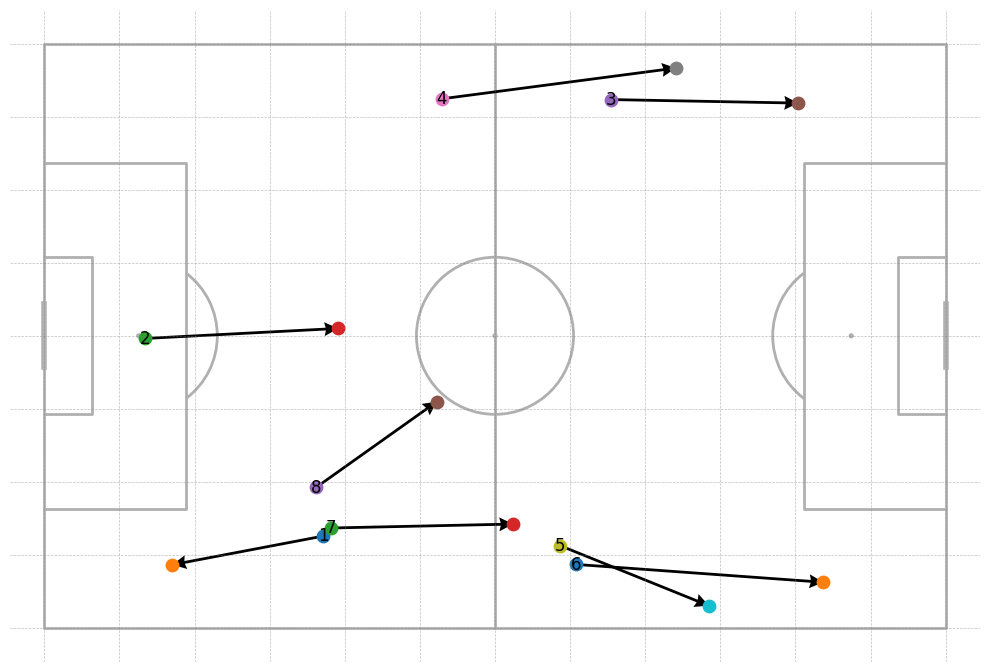

In [14]:
bp.plot_pass(complete_data, "11v11", n=2, seed=22)
    # game_format ="7v7" or "11v11" (比赛规模包括： “7v7”, "11v11")
    # n is the sample size in each transition（ n是每个transition中抽取的样本数量）
    # seed is random seed  （seed是用于随机化的数值）

In [15]:
#only keep pass events in final version(最终只保留传球数据）
pass_data = complete_data.loc[
    complete_data["Action Type"] == "Pass"].copy()
pass_data.to_csv("df_pass_sample.csv", index=False)